### Notebook used to visualize the generated datasets

In [2]:
%cd C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM

C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM


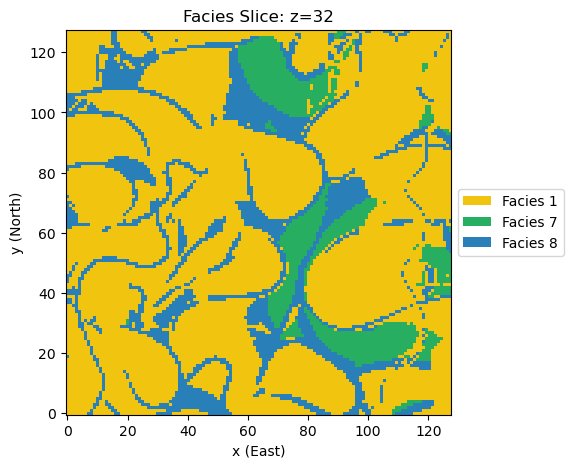

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

def visualize_facies_npz(file_path, slice_axis='z', slice_idx=None):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    # --- 1. Load and Decode ---
    data = np.load(file_path)
    fac_data = data['facies']

    # If it's One-Hot Encoded (Channels, Z, Y, X), collapse it
    # categories = [1, 7, 8]
    if fac_data.ndim == 4:
        print("Detected One-Hot encoding. Collapsing channels...")
        # argmax gives 0, 1, 2. We map these back to 1, 7, 8
        idx_map = {0: 1, 1: 7, 2: 8}
        collapsed = np.argmax(fac_data, axis=0)
        fac_vol = np.vectorize(idx_map.get)(collapsed)
    else:
        fac_vol = fac_data

    # --- 2. Slicing ---
    nz, ny, nx = fac_vol.shape
    if slice_axis == 'z':
        # Map view: y on vertical, x on horizontal
        idx = slice_idx if slice_idx is not None else nz // 2
        slc = fac_vol[idx, :, :]
        ylabel, xlabel = "y (North)", "x (East)"
    elif slice_axis == 'y':
        # XZ Cross-section: z on vertical, x on horizontal
        idx = slice_idx if slice_idx is not None else ny // 2
        slc = fac_vol[:, idx, :]  # Removed .T
        ylabel, xlabel = "z (Depth/Elevation)", "x (East)"
    else: # slice_axis == 'x'
        # YZ Cross-section: z on vertical, y on horizontal
        idx = slice_idx if slice_idx is not None else nx // 2
        slc = fac_vol[:, :, idx] # Removed .T
        ylabel, xlabel = "z (Depth/Elevation)", "y (North)"

    # --- 3. Colors & Plot ---
    facies_colors = {1: "#f1c40f", 7: "#27ae60", 8: "#2980b9"}
    colors = [facies_colors[1], "#ffffff", facies_colors[7], facies_colors[8]]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([0.5, 1.5, 6.5, 7.5, 8.5], cmap.N)

    plt.figure(figsize=(10, 5))
    plt.imshow(slc, origin='lower', cmap=cmap, norm=norm, aspect='equal')
    
    # Legend
    legend_elements = [Patch(facecolor=facies_colors[v], label=f'Facies {v}') 
                       for v in np.unique(slc) if v in facies_colors]
    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
    
    plt.title(f"Facies Slice: {slice_axis}={idx}")
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.show()

# --- Usage ---
base = os.path.join(os.getcwd(), "test_outputs")
visualize_facies_npz(os.path.join(base, "sample_46.npz"), slice_axis='z')